In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_binned_cue
import pingouin as pg

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


# Finger pre-activation (Fig. R1a)


RM-ANOVA for thumb
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.004042   4  0.001011  1.123331  0.355642  0.00334  0.832638
1  Error  0.046779  52  0.000900       NaN       NaN      NaN       NaN

RM-ANOVA for index
  Source        SS  DF        MS         F     p-unc      ng2       eps
0    cue  0.046056   4  0.011514  8.315492  0.000029  0.06841  0.472629
1  Error  0.072002  52  0.001385       NaN       NaN      NaN       NaN

RM-ANOVA for middle
  Source        SS  DF        MS         F    p-unc       ng2       eps
0    cue  0.003064   4  0.000766  0.328446  0.85761  0.001431  0.678388
1  Error  0.121275  52  0.002332       NaN      NaN       NaN       NaN

RM-ANOVA for ring
  Source        SS  DF        MS         F     p-unc       ng2       eps
0    cue  0.034885   4  0.008721  6.281116  0.000335  0.033626  0.773713
1  Error  0.072201  52  0.001388       NaN       NaN       NaN       NaN

RM-ANOVA for pinkie
  Source        SS  DF        MS

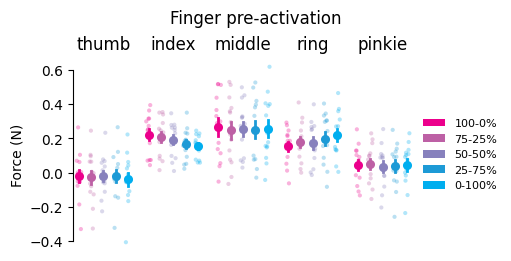

In [2]:
behav = pd.read_csv(os.path.join('data', 'behavioural', 'behaviour.trial.tsv'), sep='\t')
N = behav.sn.nunique()
behav_cue_avg = behav.groupby(['sn', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(5, 2.5), constrained_layout=True)
for f, finger in enumerate(gl.fingers):
    ax = axs[f]
    plot_binned_cue(fig, ax, behav_cue_avg, y=f'{finger}0', x='cue', show_individuals=True)
    ax.legend(frameon=False) if f<4 else None
    ax.spines[['left']].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(finger)
axs[0].tick_params(left=True)
axs[0].spines[['left']].set_visible(True)
axs[0].spines[['left']].set_bounds(-.4, .6)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Finger pre-activation')
fig.savefig(os.path.join('figures', 'preactivation.force.pdf'))
for finger in gl.fingers:
    dv = f'{finger}0'
    aov = pg.rm_anova(
        data=behav_cue_avg,
        dv=dv,
        within='cue',
        subject='sn',
        detailed=True
    )
    print(f'\nRM-ANOVA for {finger}')
    print(aov)
plt.show()